In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
project_root = Path().resolve().parent
data_dir = project_root / "data"

df_daily = pd.read_csv(data_dir / "daily_clean.csv", parse_dates=['calendarDate'])
df_act = pd.read_csv(data_dir / "activities_clean.csv", parse_dates=['date'])

print(f"daily: {df_daily.shape}")
print(f"activities: {df_act.shape}")

daily: (887, 30)
activities: (259, 32)


In [3]:
# Flag workout days
workout_dates = set(df_act['date'].dt.date)
df_daily['had_workout'] = df_daily['calendarDate'].dt.date.isin(workout_dates)

# Summary stats — cross dataset
print("=== CROSS DATASET SUMMARY ===")
print(f"Workout days:                {df_daily['had_workout'].sum()} of {len(df_daily)} days ({df_daily['had_workout'].mean()*100:.1f}%)")
print(f"Avg stress on workout days:  {df_daily[df_daily['had_workout']]['stress_avg'].mean():.1f}")
print(f"Avg stress on rest days:     {df_daily[~df_daily['had_workout']]['stress_avg'].mean():.1f}")
print(f"Avg battery end workout days:{df_daily[df_daily['had_workout']]['battery_end'].mean():.1f}")
print(f"Avg battery end rest days:   {df_daily[~df_daily['had_workout']]['battery_end'].mean():.1f}")
print(f"Resting HR improved from ~63 bpm (Dec 2023) to ~49 bpm (2024 onward) — a 14 bpm drop")
print(f"Avg battery start: {df_daily['battery_start'].mean():.1f} — consistently low, suggests incomplete overnight recovery")

=== CROSS DATASET SUMMARY ===
Workout days:                241 of 887 days (27.2%)
Avg stress on workout days:  30.3
Avg stress on rest days:     34.2
Avg battery end workout days:21.6
Avg battery end rest days:   18.3
Resting HR improved from ~63 bpm (Dec 2023) to ~49 bpm (2024 onward) — a 14 bpm drop
Avg battery start: 23.7 — consistently low, suggests incomplete overnight recovery


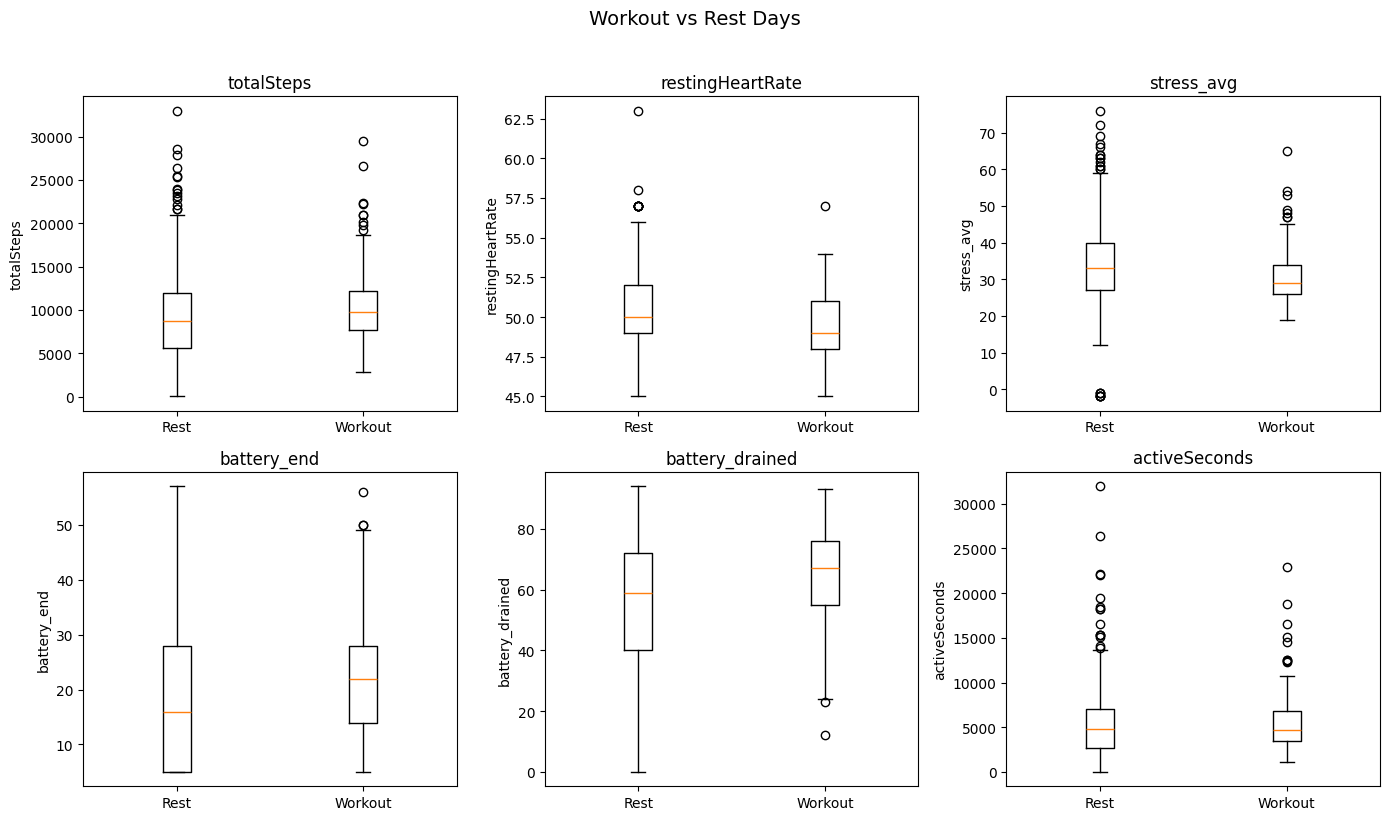

In [4]:
metrics = ['totalSteps', 'restingHeartRate', 'stress_avg', 
           'battery_end', 'battery_drained', 'activeSeconds']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    workout = df_daily[df_daily['had_workout']][metric].dropna()
    rest = df_daily[~df_daily['had_workout']][metric].dropna()
    
    axes[i].boxplot([rest, workout], tick_labels=['Rest', 'Workout'])
    axes[i].set_title(metric)
    axes[i].set_ylabel(metric)

plt.suptitle('Workout vs Rest Days', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

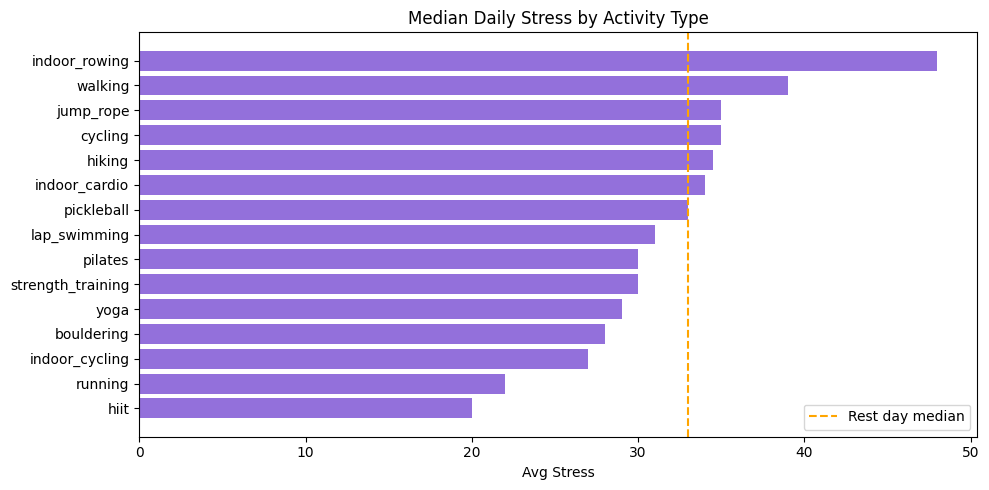

In [5]:
# Join activity type onto daily data
df_act_daily = df_act[['date', 'activityType', 'avgHr']].copy()
df_act_daily = df_act_daily.rename(columns={'date': 'calendarDate'})
df_act_daily = df_act_daily.sort_values('avgHr', ascending=False).drop_duplicates('calendarDate')

df_merged = df_daily.merge(df_act_daily, on='calendarDate', how='left')

stress_by_type = df_merged.groupby('activityType')['stress_avg'].median().sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(stress_by_type.index, stress_by_type.values, color='mediumpurple')
ax.axvline(df_daily[~df_daily['had_workout']]['stress_avg'].median(), 
           color='orange', linewidth=1.5, linestyle='--', label='Rest day median')
ax.set_title('Median Daily Stress by Activity Type')
ax.set_xlabel('Avg Stress')
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
print("=== KEY FINDINGS ===")
print(f"1. Resting HR dropped ~14 bpm (63 -> 49) between Dec 2023 and mid-2024, correlating with increased workout frequency")
print(f"2. Workout days have {df_daily[~df_daily['had_workout']]['stress_avg'].mean() - df_daily[df_daily['had_workout']]['stress_avg'].mean():.1f} pts lower avg stress than rest days")
print(f"3. Battery end is higher on workout days ({df_daily[df_daily['had_workout']]['battery_end'].mean():.1f}) vs rest days ({df_daily[~df_daily['had_workout']]['battery_end'].mean():.1f}) despite higher drain")
print(f"4. Avg battery start of {df_daily['battery_start'].mean():.1f} suggests chronic incomplete overnight recovery")
print(f"5. HIIT and indoor cycling days associated with lowest stress readings")
print(f"6. Steps are consistent across workout and rest days — exercise and daily movement are independent behaviors")
print(f"7. Saturday most active day, Monday least active — likely reflects work schedule")

=== KEY FINDINGS ===
1. Resting HR dropped ~14 bpm (63 -> 49) between Dec 2023 and mid-2024, correlating with increased workout frequency
2. Workout days have 3.9 pts lower avg stress than rest days
3. Battery end is higher on workout days (21.6) vs rest days (18.3) despite higher drain
4. Avg battery start of 23.7 suggests chronic incomplete overnight recovery
5. HIIT and indoor cycling days associated with lowest stress readings
6. Steps are consistent across workout and rest days — exercise and daily movement are independent behaviors
7. Saturday most active day, Monday least active — likely reflects work schedule
